In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

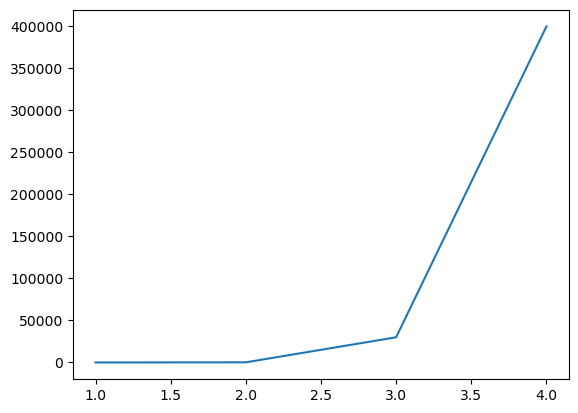

In [2]:
plt.plot([1,2,3,4],[10,200,30000,400000]);

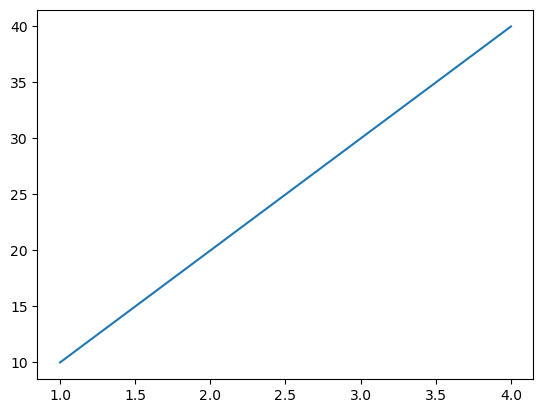

In [3]:
x=[1,2,3,4]
y=[10,20,30,40]
plt.plot(x,y)

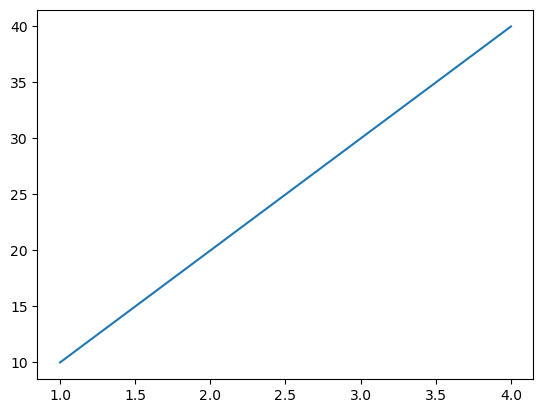

In [4]:
fig, ax=plt.subplots()
ax.plot(x,y)

## Anatomy of a figure


In [5]:
x=[1,2,3,4]
y=[11,22,33,44]

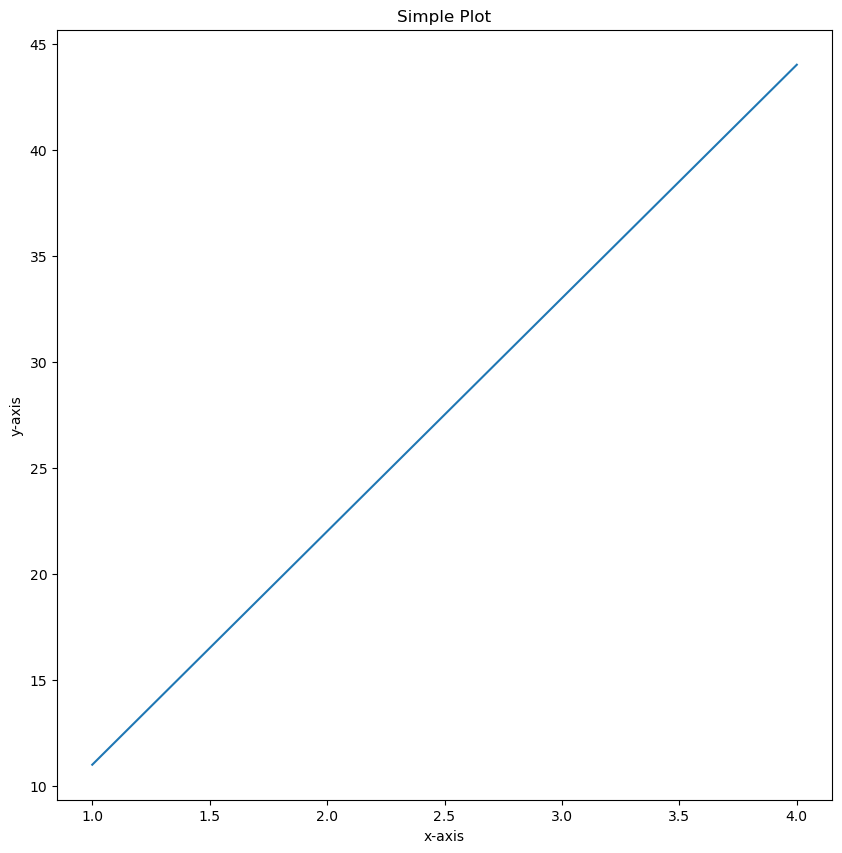

In [6]:
fig,ax=plt.subplots(figsize=(10,10))
ax.plot(x,y)
ax.set(title="Simple Plot",
       xlabel="x-axis",
       ylabel="y-axis")
fig.savefig("images/sample-plot.png")

## Making figures with numpy array


In [7]:
import numpy as np

In [8]:
x=np.linspace(0,100,100)

In [9]:
x[:10]

array([0.        , 1.01010101, 2.02020202, 3.03030303, 4.04040404,
       5.05050505, 6.06060606, 7.07070707, 8.08080808, 9.09090909])

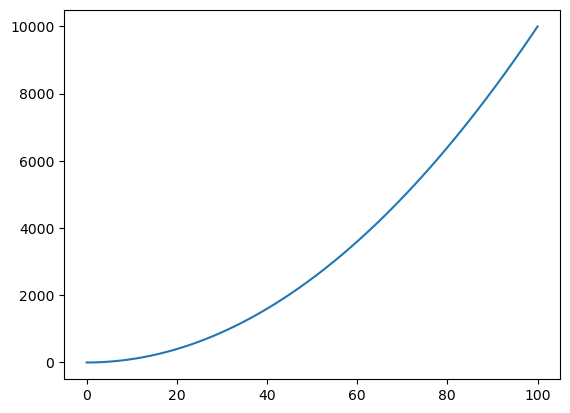

In [10]:
fig,ax=plt.subplots()
ax.plot(x,x**2)

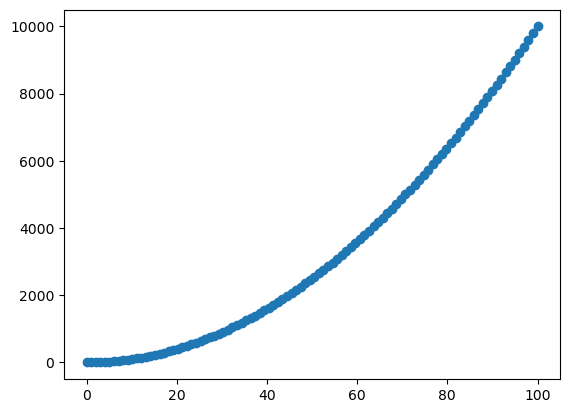

In [11]:
fig,ax=plt.subplots()
ax.scatter(x,x**2)

In [12]:
butter={"almond":34,
        "butter":45,
       "chocolate":12}


<BarContainer object of 3 artists>

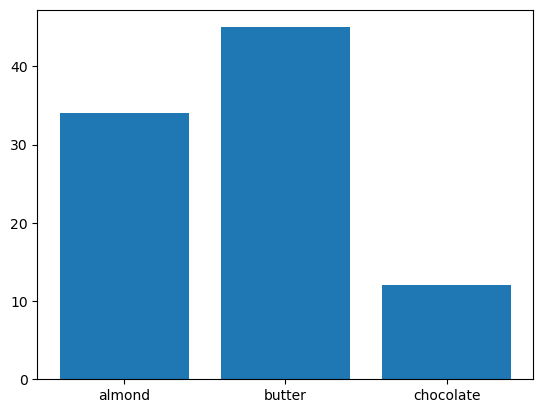

In [13]:
fig,ax=plt.subplots()
ax.bar(butter.keys(),height=butter.values())

## Multiple subplots

(array([  4.,  16.,  75., 169., 246., 261., 145.,  58.,  22.,   4.]),
 array([-3.33209045, -2.66128017, -1.9904699 , -1.31965962, -0.64884935,
         0.02196092,  0.6927712 ,  1.36358147,  2.03439175,  2.70520202,
         3.37601229]),
 <BarContainer object of 10 artists>)

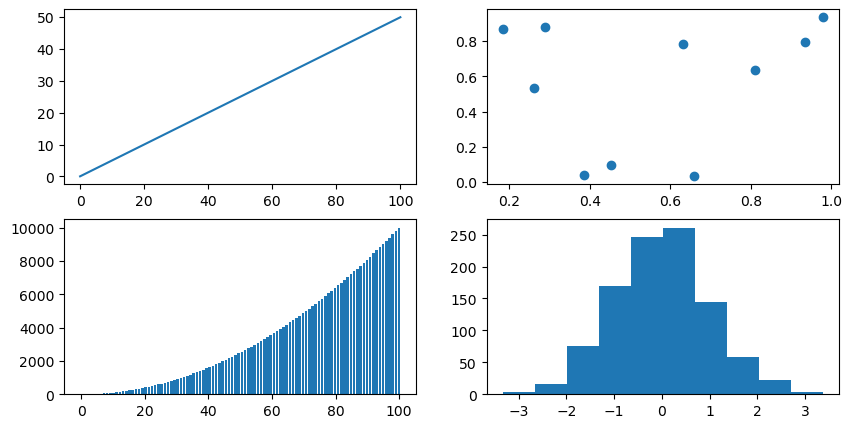

In [14]:
fig, ((ax1,ax2),(ax3,ax4))=plt.subplots(nrows=2,
                                      ncols=2,
                                      figsize=(10,5))
ax1.plot(x,x/2)
ax2.scatter(np.random.random(10),np.random.random(10))
ax3.bar(x,x**2)
ax4.hist(np.random.randn(1000))

## Different way to create subplot

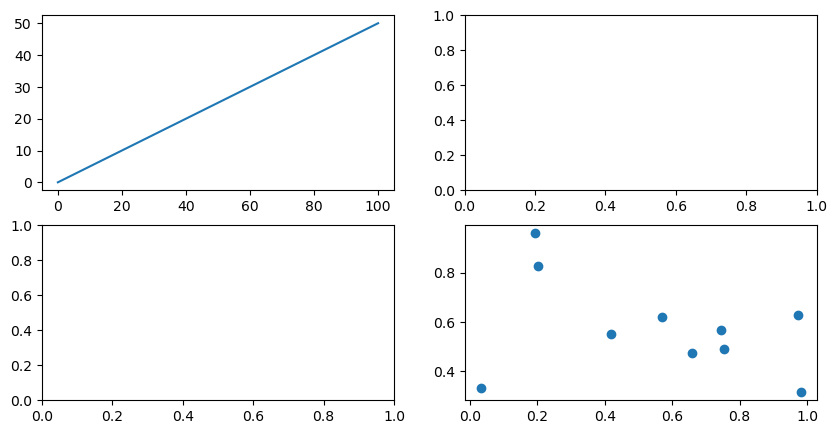

In [15]:
fig, ax=plt.subplots(nrows=2,
                     ncols=2,
                     figsize=(10,5))
ax[0,0].plot(x,x/2)
ax[1,1].scatter(np.random.rand(10),np.random.rand(10))

## Plotting from pandas DataFrame

In [16]:
import pandas as pd

<Axes: >

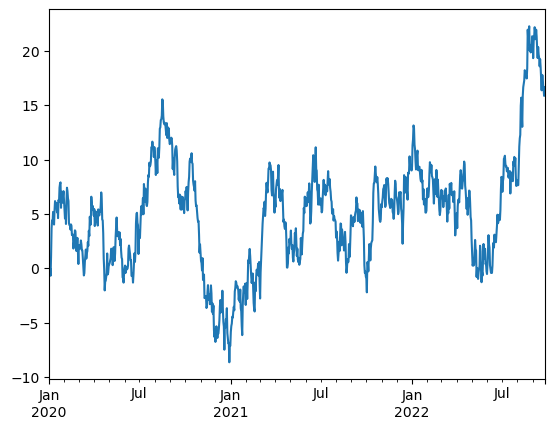

In [17]:
ts=pd.Series(np.random.randn(1000),
             index=pd.date_range("1/1/2020",
                                 periods=1000))
ts=ts.cumsum()
ts.plot()

## Plotting from Pandas DataFrame2

In [18]:
car_sales=pd.read_csv("car-sales.csv")

In [19]:
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,"$4,000.00"
1,Honda,Red,87899,4,"$5,000.00"
2,Toyota,Blue,32549,3,"$7,000.00"
3,BMW,Black,11179,5,"$22,000.00"
4,Nissan,White,213095,4,"$3,500.00"
5,Toyota,Green,99213,4,"$4,500.00"
6,Honda,Blue,45698,4,"$7,500.00"
7,Honda,Blue,54738,4,"$7,000.00"
8,Toyota,White,60000,4,"$6,250.00"
9,Nissan,White,31600,4,"$9,700.00"


In [20]:
car_sales["Price"] = car_sales["Price"].str.replace(r'[\$,.]', '', regex=True)

In [21]:
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,400000
1,Honda,Red,87899,4,500000
2,Toyota,Blue,32549,3,700000
3,BMW,Black,11179,5,2200000
4,Nissan,White,213095,4,350000
5,Toyota,Green,99213,4,450000
6,Honda,Blue,45698,4,750000
7,Honda,Blue,54738,4,700000
8,Toyota,White,60000,4,625000
9,Nissan,White,31600,4,970000


In [22]:
type(car_sales["Price"])

pandas.core.series.Series

In [23]:
# Remove the last 2 zeros

In [24]:
car_sales["Price"]=car_sales["Price"].str[:-2]

In [25]:
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,4000
1,Honda,Red,87899,4,5000
2,Toyota,Blue,32549,3,7000
3,BMW,Black,11179,5,22000
4,Nissan,White,213095,4,3500
5,Toyota,Green,99213,4,4500
6,Honda,Blue,45698,4,7500
7,Honda,Blue,54738,4,7000
8,Toyota,White,60000,4,6250
9,Nissan,White,31600,4,9700


In [26]:
car_sales["Sale Date"]=pd.date_range("1/1/2020",periods=(len(car_sales)))

In [27]:
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Sale Date
0,Toyota,White,150043,4,4000,2020-01-01
1,Honda,Red,87899,4,5000,2020-01-02
2,Toyota,Blue,32549,3,7000,2020-01-03
3,BMW,Black,11179,5,22000,2020-01-04
4,Nissan,White,213095,4,3500,2020-01-05
5,Toyota,Green,99213,4,4500,2020-01-06
6,Honda,Blue,45698,4,7500,2020-01-07
7,Honda,Blue,54738,4,7000,2020-01-08
8,Toyota,White,60000,4,6250,2020-01-09
9,Nissan,White,31600,4,9700,2020-01-10


In [28]:
car_sales["Total Sales"]=car_sales["Price"].astype(int).cumsum()

In [29]:
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Sale Date,Total Sales
0,Toyota,White,150043,4,4000,2020-01-01,4000
1,Honda,Red,87899,4,5000,2020-01-02,9000
2,Toyota,Blue,32549,3,7000,2020-01-03,16000
3,BMW,Black,11179,5,22000,2020-01-04,38000
4,Nissan,White,213095,4,3500,2020-01-05,41500
5,Toyota,Green,99213,4,4500,2020-01-06,46000
6,Honda,Blue,45698,4,7500,2020-01-07,53500
7,Honda,Blue,54738,4,7000,2020-01-08,60500
8,Toyota,White,60000,4,6250,2020-01-09,66750
9,Nissan,White,31600,4,9700,2020-01-10,76450


<Axes: xlabel='Sale Date'>

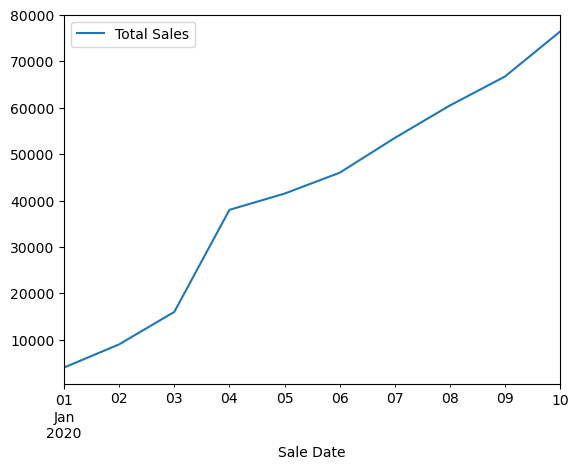

In [30]:
car_sales.plot(x="Sale Date",y="Total Sales")

In [31]:
car_sales["Price"]=car_sales["Price"].astype(int)


<Axes: xlabel='Odometer (KM)', ylabel='Price'>

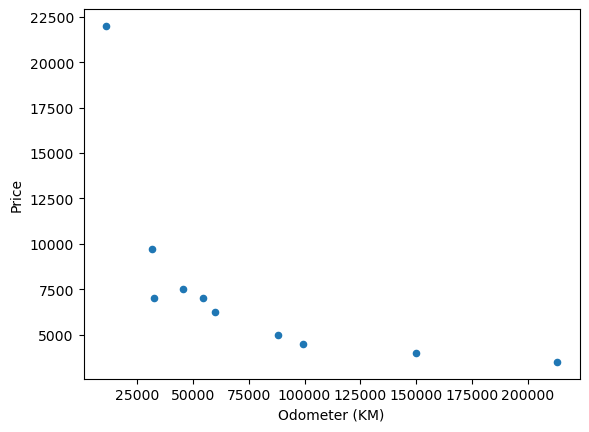

In [32]:
car_sales.plot(x="Odometer (KM)",y="Price",kind="scatter")

In [33]:
# what about bar graph?


In [34]:
x=np.random.rand(5,4)

In [35]:
df=pd.DataFrame(x,columns=('a','b','c','d'))
df

,a,b,c,d
0,0.077229,0.662029,0.590256,0.783251
1,0.738822,0.510619,0.936888,0.558578
2,0.674961,0.926608,0.539009,0.221476
3,0.510345,0.996870,0.109442,0.453128
4,0.357609,0.293373,0.000115,0.881749


<Axes: >

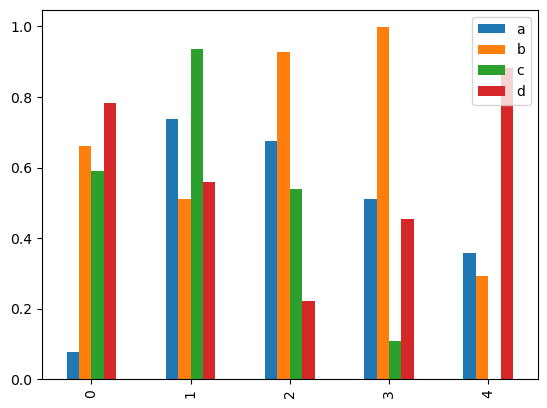

In [36]:
df.plot.bar()

<Axes: xlabel='Make'>

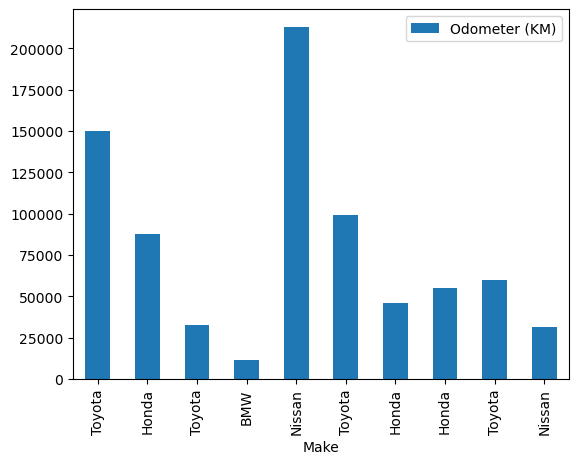

In [37]:
car_sales.plot(x="Make",y="Odometer (KM)", kind="bar")

In [38]:
#What about historgrams

<Axes: ylabel='Frequency'>

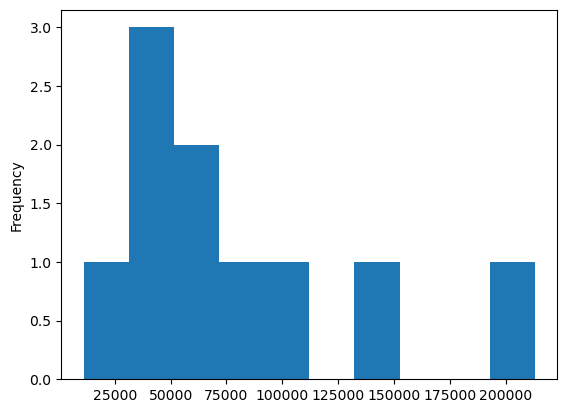

In [39]:
car_sales["Odometer (KM)"].plot.hist()

In [ ]:
car_sales["Odometer (KM)"].plot.hist(bins=10)

## On another dataset

In [40]:
heart_disease=pd.read_csv("heart-disease.csv")

In [42]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Creating a histogram out of it

<Axes: ylabel='Frequency'>

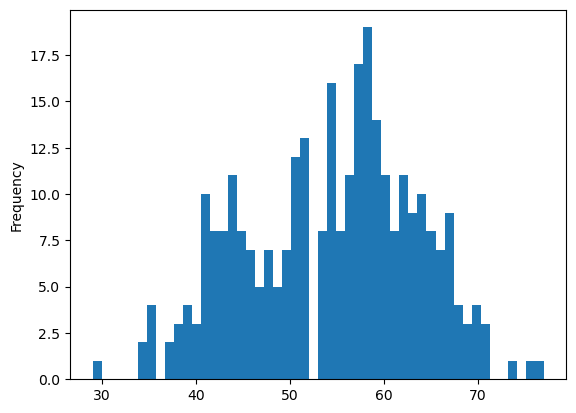

In [44]:
heart_disease["age"].plot.hist(bins=50)

array([<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>],
      dtype=object)

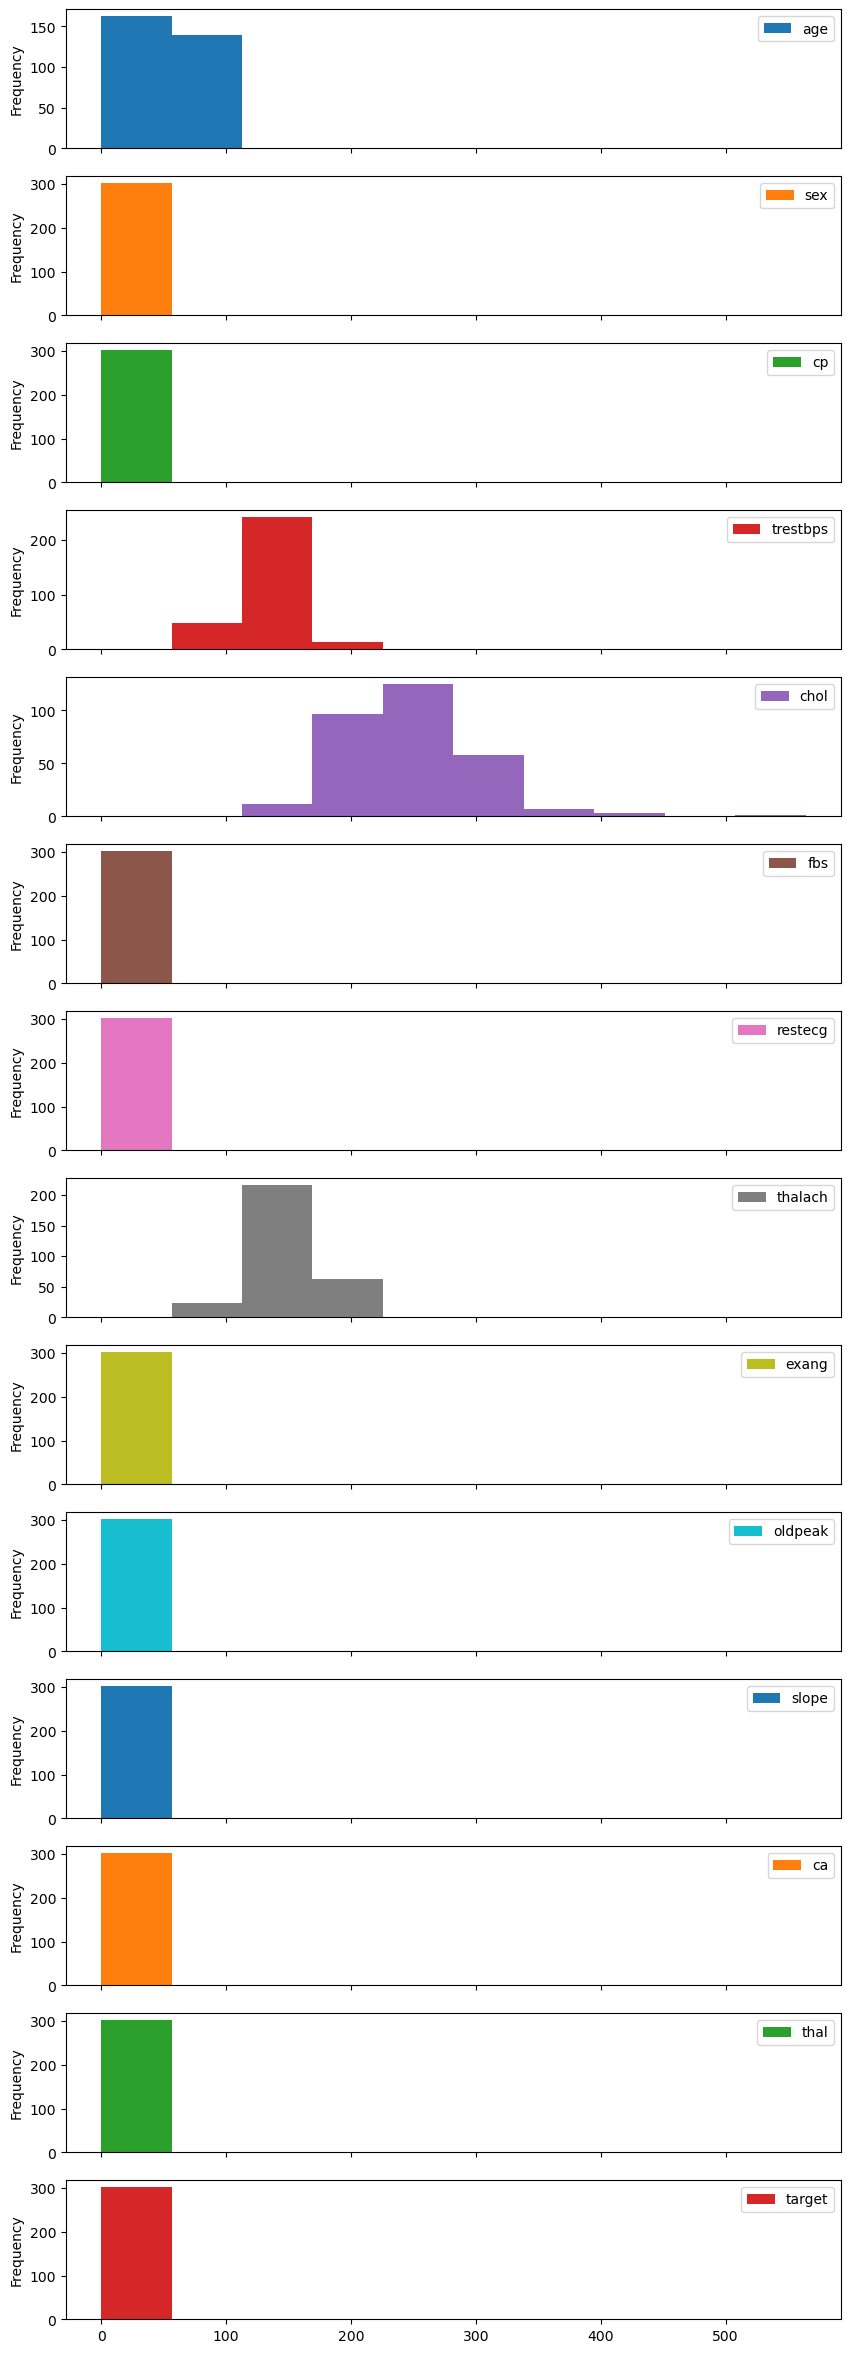

In [45]:
heart_disease.plot.hist(figsize=(10,30),subplots=True)

## Plotting for dataFrame 5

In [46]:
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [47]:
age_50=heart_disease[heart_disease["age"]>50]

In [49]:
age_50.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1


<Axes: xlabel='age', ylabel='chol'>

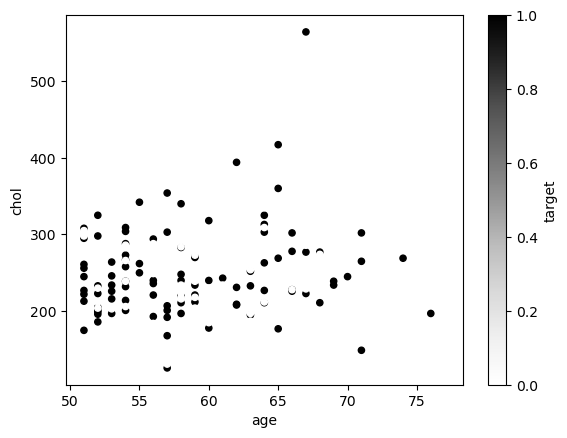

In [51]:
age_50.plot(kind="scatter",
            x="age",
            y="chol",
            c="target")

(45.0, 100.0)

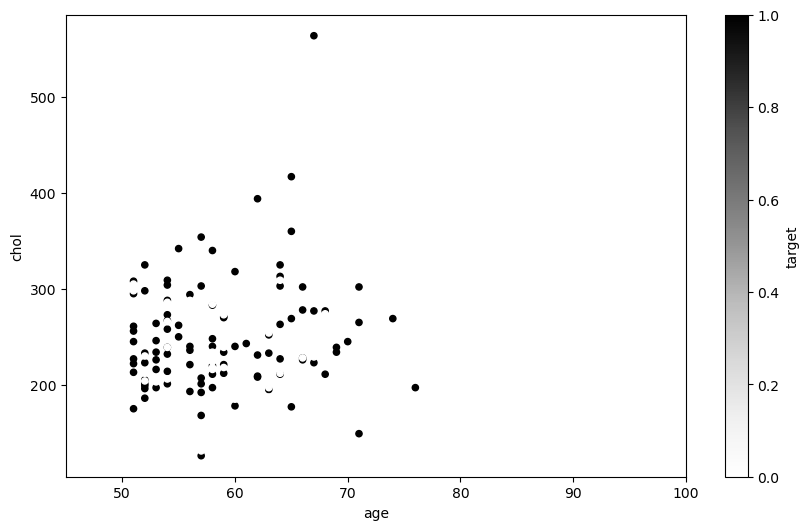

In [58]:
fig, ax=plt.subplots(figsize=(10,6))
age_50.plot(kind="scatter",
             x="age",
             y="chol",
             c="target",
             ax=ax)
ax.set_xlim([45,100])